# **DEFENSE FIGURE — the AMOC manifold is 2-D (3-D view)**
---
**Purpose (thesis defense).** A 3-D scatter of every RAPID profile in the space of its
first three PCA scores (PC1, PC2, PC3). With honest equal-unit axes the cloud is a
**flat sheet lying in the PC1–PC2 plane**: PC1 (89.8%) + PC2 (8.0%) hold 97.9% of the
variance, while PC3 adds only 1.6% — the sheet's thickness. Points are coloured by the
**independently observed** RAPID AMOC transport, showing the plane is organised by real
AMOC strength (PC1 = intensity). The three days from the H2 figure are marked.

Standalone; copies NB03's loading + PCA. **Outputs:** the honest equal-scale figure
`../img/H2_manifold_3D.png` (+ `_transparent`), and a light-background presentation
'hero' view `../img/H2_manifold_3D_light.png` (+ `_transparent`) with a gentle cosmetic
thickness for slides.

In [1]:
# --- Setup (data-loading logic copied from NB03) ---
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_CODE = NOTEBOOK_DIR.parent
if str(PROJECT_CODE) not in sys.path:
    sys.path.insert(0, str(PROJECT_CODE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from pipeline.data_loading import load_rapid_vertical, load_rapid_transports

IMG_DIR = (NOTEBOOK_DIR.parent / "img")
IMG_DIR.mkdir(parents=True, exist_ok=True)
print("Figures ->", IMG_DIR.resolve())

Figures -> C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\04_Activation_Phase\04_Code\img


In [2]:
# --- Load profiles + PCA (as NB03), colour by observed AMOC transport ---
ds_vert = load_rapid_vertical()
profiles = ds_vert['stream_function_mar'].transpose('time', 'depth')
X = profiles.values
valid_days = ~np.isnan(X).any(axis=1)
X_clean = X[valid_days]
times_clean = pd.to_datetime(ds_vert['time'].values[valid_days])

pca = PCA()
scores = pca.fit_transform(X_clean)
pc1, pc2, pc3 = scores[:, 0], scores[:, 1], scores[:, 2]
expl = pca.explained_variance_ratio_
print(f"PC1={expl[0]*100:.2f}%  PC2={expl[1]*100:.2f}%  PC3={expl[2]*100:.2f}%  "
      f"plane(PC1+PC2)={expl[:2].sum()*100:.2f}%")
print(f"std ratio PC1:PC2:PC3 = {pc1.std()/pc3.std():.1f} : {pc2.std()/pc3.std():.1f} : 1")

# Observed AMOC strength (RAPID moc_mar_hc10), aligned by timestamp -> colour
ds_tr = load_rapid_transports()
amoc_full = pd.Series(ds_tr['moc_mar_hc10'].values,
                      index=pd.to_datetime(ds_tr['time'].values))
amoc = amoc_full.reindex(times_clean).values
ok = ~np.isnan(amoc)
print(f"AMOC transport colour: {np.nanmin(amoc):.1f}..{np.nanmax(amoc):.1f} Sv, "
      f"NaNs={int((~ok).sum())}")
print(f"corr(PC1, AMOC) = {np.corrcoef(pc1[ok], amoc[ok])[0,1]:+.3f}  "
      f"(PC1 tracks observed AMOC intensity)")

# the three representative days from the H2 figure, for context
day = times_clean.normalize()
def pick(date_str, direction):
    m = np.where(day.values == np.datetime64(date_str))[0]
    return int(m[np.argmax(pc1[m])] if direction == "max" else m[np.argmin(pc1[m])])
_s = pick("2015-11-18", "max"); _w = pick("2014-03-08", "min"); _a = pick("2009-12-23", "min")
marks = [
    ("Strong  2015-11-18",    (pc1[_s], pc2[_s], pc3[_s]), "#111111", "*"),
    ("Weak  2014-03-08",      (pc1[_w], pc2[_w], pc3[_w]), "#4D4D4D", "^"),
    ("Anomalous  2009-12-23", (pc1[_a], pc2[_a], pc3[_a]), "#B2182B", "o"),
]
for lab, p, _c, _m in marks:
    print(f"{lab:24s} PC1={p[0]:+8.1f}  PC2={p[1]:+7.1f}  PC3={p[2]:+6.1f}")

PC1=89.82%  PC2=8.03%  PC3=1.57%  plane(PC1+PC2)=97.86%
std ratio PC1:PC2:PC3 = 7.6 : 2.3 : 1


AMOC transport colour: -4.3..32.3 Sv, NaNs=17
corr(PC1, AMOC) = +0.888  (PC1 tracks observed AMOC intensity)
Strong  2015-11-18       PC1=   +88.7  PC2=  +18.6  PC3=  -3.3
Weak  2014-03-08         PC1=   -92.9  PC2=  -28.5  PC3=  -6.1
Anomalous  2009-12-23    PC1=  -240.4  PC2=  -29.8  PC3=  +5.5


saved: H2_manifold_3D.png | H2_manifold_3D_transparent.png


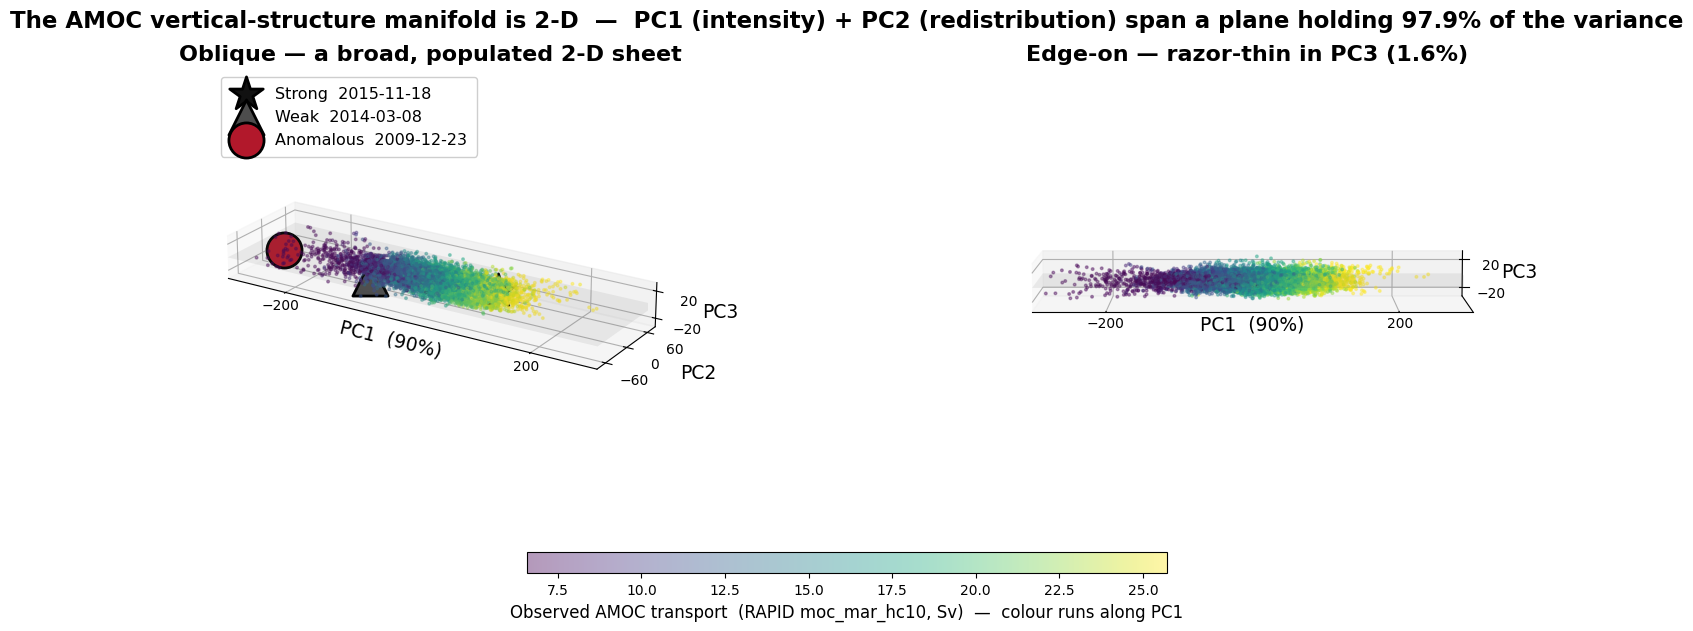

In [3]:
# --- 3-D figure: the AMOC manifold is a flat PC1-PC2 sheet ---
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the '3d' projection)

plt.rcParams.update({
    'font.size': 13, 'axes.titlesize': 16, 'axes.labelsize': 13.5,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'font.family': 'DejaVu Sans',
})

CMAP = 'viridis'
vmin, vmax = np.nanpercentile(amoc, [2, 98])

# Honest equal-unit limits: 'flat' must not be an axis-scaling artefact
Lx, Ly, Lz = [float(np.abs(v).max()) * 1.05 for v in (pc1, pc2, pc3)]

def draw(ax, elev, azim, title, edge_on=False):
    gx, gy = np.meshgrid(np.linspace(-Lx, Lx, 2), np.linspace(-Ly, Ly, 2))
    ax.plot_surface(gx, gy, np.zeros_like(gx), color='0.5', alpha=0.10,
                    linewidth=0, zorder=0)                       # PC1-PC2 plane (PC3=0)
    sc = ax.scatter(pc1, pc2, pc3, c=amoc, cmap=CMAP, vmin=vmin, vmax=vmax,
                    s=3.5, alpha=0.40, depthshade=False, zorder=2)
    ax.set_xlim(-Lx, Lx); ax.set_ylim(-Ly, Ly); ax.set_zlim(-Lz, Lz)
    ax.set_box_aspect((Lx, Ly, Lz))
    ax.set_xticks([-200, 200]); ax.set_zticks([-20, 20])   # drop centre ticks (avoid label collisions)
    ax.set_xlabel('PC1  (90%)', labelpad=12)
    ax.set_zlabel('PC3', labelpad=2)                       # variance %s live in the title
    if edge_on:                       # PC2 is the compressed axis here — hide its clutter
        ax.set_yticks([]); ax.set_ylabel('')
    else:
        ax.set_yticks([-60, 0, 60]); ax.set_ylabel('PC2', labelpad=8)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title, fontweight='bold', pad=6)
    return sc

fig = plt.figure(figsize=(16, 6.6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax1.set_position([0.01, 0.24, 0.46, 0.66])
ax2.set_position([0.52, 0.24, 0.46, 0.66])

sc = draw(ax1, 22, -58, 'Oblique — a broad, populated 2-D sheet')
draw(ax2, 7, -90, 'Edge-on — razor-thin in PC3 (1.6%)', edge_on=True)

# Mark the three representative days (white halo + black ring so they pop out of the cloud)
for lab, p, col, mk in marks:
    ax1.scatter([p[0]], [p[1]], [p[2]], s=780, c='white', marker=mk,
                edgecolor='white', linewidth=0, depthshade=False, zorder=6)   # halo
    ax1.scatter([p[0]], [p[1]], [p[2]], s=640, c=col, marker=mk,
                edgecolor='black', linewidth=2.0, depthshade=False, zorder=7, label=lab)
ax1.legend(loc='upper left', fontsize=11.5, framealpha=0.95, borderpad=0.6)

# Horizontal colourbar along the bottom (kept clear of the 3-D axes)
cax = fig.add_axes([0.30, 0.135, 0.40, 0.032])
cbar = fig.colorbar(sc, cax=cax, orientation='horizontal')
cbar.set_label('Observed AMOC transport  (RAPID moc_mar_hc10, Sv)  —  colour runs along PC1',
               fontsize=12)

fig.suptitle('The AMOC vertical-structure manifold is 2-D  —  PC1 (intensity) + PC2 '
             f'(redistribution) span a plane holding {expl[:2].sum()*100:.1f}% of the variance',
             fontsize=16.5, fontweight='bold', y=0.99)

f_std   = IMG_DIR / "H2_manifold_3D.png"
f_trans = IMG_DIR / "H2_manifold_3D_transparent.png"
fig.savefig(f_std,   dpi=200, facecolor='white', bbox_inches='tight')
fig.savefig(f_trans, dpi=300, transparent=True,  bbox_inches='tight')
print("saved:", f_std.name, "|", f_trans.name)
plt.show()

saved: H2_manifold_3D_light.png | H2_manifold_3D_light_transparent.png


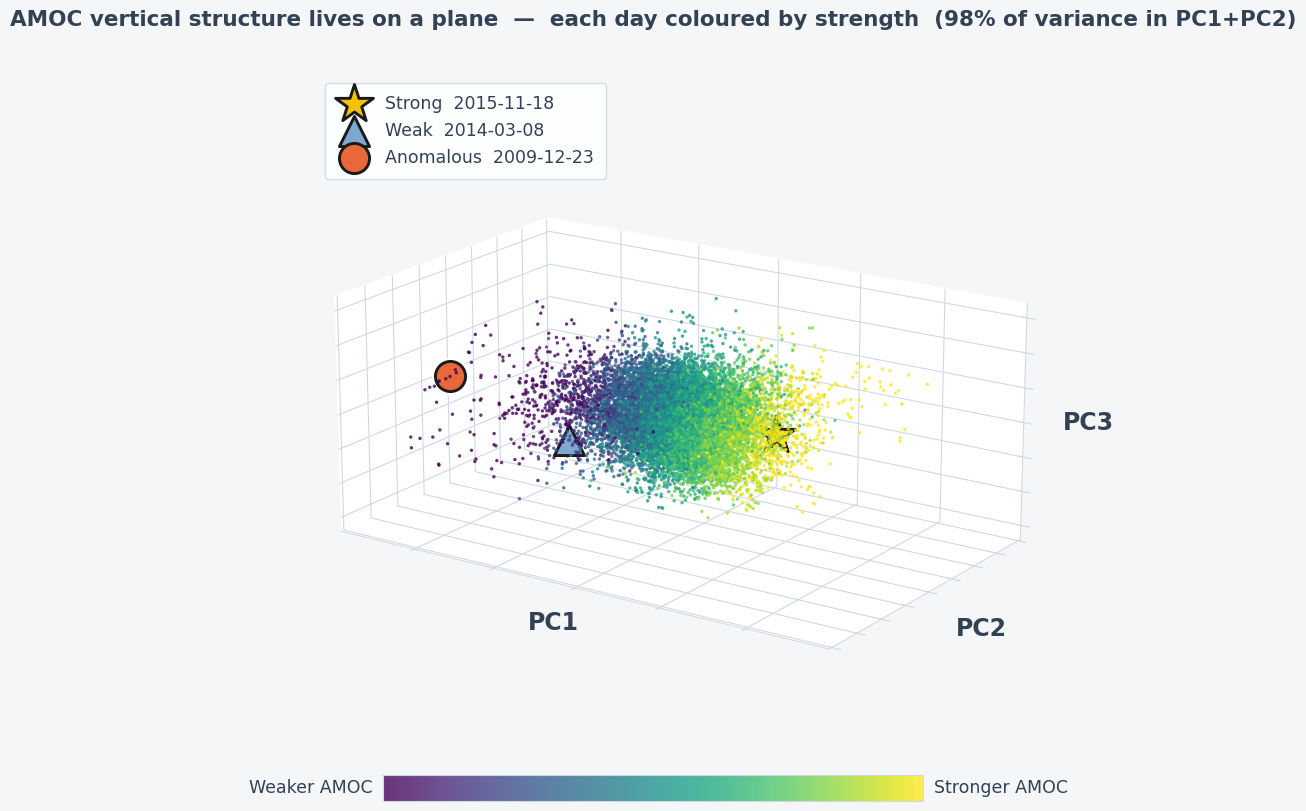

In [4]:
# --- Presentation 'hero' view: single elegant sheet on a LIGHT background ---
# NOTE: cosmetic vertical exaggeration (box_aspect) for looks — a slide visual,
# not the honest equal-scale flatness proof in the previous cell.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.rcParams.update({'font.family': 'DejaVu Sans',
                     'grid.color': '#D2D8E0', 'grid.linewidth': 0.8})
BG   = '#F4F6F8'          # light background
PANE = (1, 1, 1, 1.0)     # white panes
GRID = '#D2D8E0'
INK  = '#334155'          # slate ink for labels

vmin, vmax = np.nanpercentile(amoc, [2, 98])
Lx = float(np.abs(pc1).max()) * 1.03
Ly = float(np.abs(pc2).max()) * 1.03
Lz = float(np.abs(pc3).max()) * 1.10

fig = plt.figure(figsize=(13.5, 9.2), facecolor=BG)
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor(BG)

sc = ax.scatter(pc1, pc2, pc3, c=amoc, cmap='viridis', vmin=vmin, vmax=vmax,
                s=6, alpha=0.80, depthshade=False, linewidths=0)

mstyle = {"Strong  2015-11-18":    ('*', '#F2C300', 820),   # star reads smaller -> larger
          "Weak  2014-03-08":      ('^', '#7FA8D0', 470),
          "Anomalous  2009-12-23": ('o', '#E8683A', 470)}
for lab, p, _c, _m in marks:
    mk, col, sz = mstyle[lab]
    ax.scatter([p[0]], [p[1]], [p[2]], s=sz * 1.55, c='white', marker=mk,
               linewidths=0, depthshade=False, zorder=6)                 # halo
    ax.scatter([p[0]], [p[1]], [p[2]], s=sz, c=col, marker=mk,
               edgecolor='#1A1A1A', linewidth=2.1, depthshade=False, zorder=7, label=lab)

ax.set_xlim(-Lx, Lx); ax.set_ylim(-Ly, Ly); ax.set_zlim(-Lz, Lz)
ax.set_box_aspect((2.0, 1.25, 0.85))     # cosmetic: gentle thickness, rectangular, not squished
ax.view_init(elev=18, azim=-56)

for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.set_ticklabels([])
    axis.set_pane_color(PANE)
    axis.line.set_color(GRID)
    axis._axinfo['grid'].update(color=GRID, linewidth=0.8)
ax.tick_params(colors=GRID, length=0)
ax.set_xlabel('PC1', color=INK, fontsize=17, labelpad=6, fontweight='bold')
ax.set_ylabel('PC2', color=INK, fontsize=17, labelpad=6, fontweight='bold')
ax.set_zlabel('PC3', color=INK, fontsize=17, labelpad=4, fontweight='bold')

ax.legend(loc='upper left', fontsize=12.5, frameon=True, framealpha=0.9,
          edgecolor=GRID, borderpad=0.7, labelcolor=INK)

cax = fig.add_axes([0.30, 0.09, 0.40, 0.028])
cbar = fig.colorbar(sc, cax=cax, orientation='horizontal')
cbar.set_ticks([]); cbar.outline.set_edgecolor(GRID)
cax.text(-0.02, 0.5, 'Weaker AMOC', transform=cax.transAxes, ha='right', va='center',
         fontsize=12.5, color=INK)
cax.text(1.02, 0.5, 'Stronger AMOC', transform=cax.transAxes, ha='left', va='center',
         fontsize=12.5, color=INK)

fig.suptitle('AMOC vertical structure lives on a plane  —  each day coloured by strength'
             f'  ({expl[:2].sum()*100:.0f}% of variance in PC1+PC2)',
             color=INK, fontsize=15.5, fontweight='bold', y=0.95)

f_std   = IMG_DIR / "H2_manifold_3D_light.png"
f_trans = IMG_DIR / "H2_manifold_3D_light_transparent.png"
fig.savefig(f_std,   dpi=220, facecolor=BG,   bbox_inches='tight')
fig.savefig(f_trans, dpi=300, transparent=True, bbox_inches='tight')
print("saved:", f_std.name, "|", f_trans.name)
plt.show()

saved: H2_manifold_3D_light_closeup.png | H2_manifold_3D_light_closeup_transparent.png


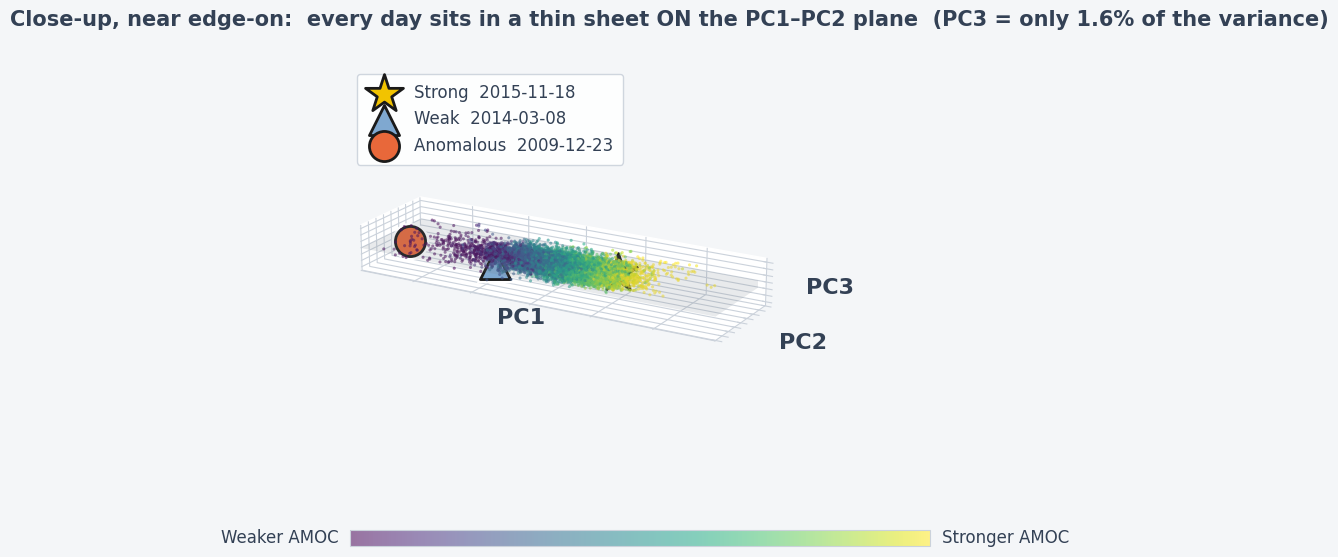

In [5]:
# --- Close-up, near edge-on: shows the data sits in a thin sheet ON the plane ---
# HONEST equal-unit scale here (unlike the 'hero' cell) so the flatness is real.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.rcParams.update({'font.family': 'DejaVu Sans',
                     'grid.color': '#CBD2DB', 'grid.linewidth': 0.8})
BG = '#F4F6F8'; PANE = (1, 1, 1, 1.0); GRID = '#CBD2DB'; INK = '#334155'
vmin, vmax = np.nanpercentile(amoc, [2, 98])
Lx = float(np.abs(pc1).max()) * 1.03
Ly = float(np.abs(pc2).max()) * 1.03
Lz = float(np.abs(pc3).max()) * 1.15

fig = plt.figure(figsize=(14.5, 6.2), facecolor=BG)
ax = fig.add_subplot(111, projection='3d'); ax.set_facecolor(BG)
ax.set_position([0.02, 0.20, 0.80, 0.66])

# the PC1-PC2 plane (PC3 = 0) that the points hug
gx, gy = np.meshgrid(np.linspace(-Lx, Lx, 2), np.linspace(-Ly, Ly, 2))
ax.plot_surface(gx, gy, np.zeros_like(gx), color='#9AA7B4', alpha=0.16, linewidth=0, zorder=0)

sc = ax.scatter(pc1, pc2, pc3, c=amoc, cmap='viridis', vmin=vmin, vmax=vmax,
                s=5, alpha=0.55, depthshade=False, linewidths=0, zorder=2)

mstyle = {"Strong  2015-11-18": ('*', '#F2C300', 820),
          "Weak  2014-03-08":   ('^', '#7FA8D0', 470),
          "Anomalous  2009-12-23": ('o', '#E8683A', 470)}
for lab, p, _c, _m in marks:
    mk, col, sz = mstyle[lab]
    ax.scatter([p[0]], [p[1]], [p[2]], s=sz * 1.55, c='white', marker=mk,
               linewidths=0, depthshade=False, zorder=6)
    ax.scatter([p[0]], [p[1]], [p[2]], s=sz, c=col, marker=mk, edgecolor='#1A1A1A',
               linewidth=2.0, depthshade=False, zorder=7, label=lab)

ax.set_xlim(-Lx, Lx); ax.set_ylim(-Ly, Ly); ax.set_zlim(-Lz, Lz)
ax.set_box_aspect((Lx, Ly, Lz))          # HONEST equal-unit scale -> flatness is real
ax.view_init(elev=19, azim=-60)

for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.set_ticklabels([]); axis.set_pane_color(PANE); axis.line.set_color(GRID)
    axis._axinfo['grid'].update(color=GRID, linewidth=0.8)
ax.tick_params(colors=GRID, length=0)
ax.set_xlabel('PC1', color=INK, fontsize=16, labelpad=4, fontweight='bold')
ax.set_ylabel('PC2', color=INK, fontsize=16, labelpad=4, fontweight='bold')
ax.set_zlabel('PC3', color=INK, fontsize=16, labelpad=2, fontweight='bold')
ax.legend(loc='upper left', fontsize=12, frameon=True, framealpha=0.9,
          edgecolor=GRID, borderpad=0.6, labelcolor=INK)

cax = fig.add_axes([0.28, 0.085, 0.40, 0.026])
cbar = fig.colorbar(sc, cax=cax, orientation='horizontal')
cbar.set_ticks([]); cbar.outline.set_edgecolor(GRID)
cax.text(-0.02, 0.5, 'Weaker AMOC', transform=cax.transAxes, ha='right', va='center', fontsize=12, color=INK)
cax.text(1.02, 0.5, 'Stronger AMOC', transform=cax.transAxes, ha='left', va='center', fontsize=12, color=INK)

fig.suptitle('Close-up, near edge-on:  every day sits in a thin sheet ON the PC1–PC2 plane'
             f'  (PC3 = only {expl[2]*100:.1f}% of the variance)',
             color=INK, fontsize=15, fontweight='bold', y=0.95)

f_std   = IMG_DIR / "H2_manifold_3D_light_closeup.png"
f_trans = IMG_DIR / "H2_manifold_3D_light_closeup_transparent.png"
fig.savefig(f_std,   dpi=220, facecolor=BG,   bbox_inches='tight')
fig.savefig(f_trans, dpi=300, transparent=True, bbox_inches='tight')
print("saved:", f_std.name, "|", f_trans.name)
plt.show()